# Load Libraries

In [1]:
options(future.globals.maxSize = 1000000 * 1024^2)
set.seed(12345)
# ## We load the required packages
# === Single-Cell Analysis Libraries ===
library(Seurat)               # Comprehensive toolkit for single-cell RNA-seq analysis
library(SingleCellExperiment) # Framework for storing and manipulating single-cell data
library(muscat)               # Multi-sample, multi-group single-cell RNA-seq analysis tools
library(dreamlet)             # Supports single-cell RNA-seq data analysis with linear mixed models

# === Visualization Libraries ===
library(ComplexHeatmap)       # Advanced heatmap visualization library
library(circlize)             # Circular visualization of genomic and other data
library(RColorBrewer)         # Provides color palettes for data visualization

# === Data Manipulation Libraries ===
library(dplyr)                # Grammar of data manipulation, focused on data frames
library(tidyr)                # Tools for tidying messy data into analyzable formats
library(tidyverse)            # Collection of R packages for data science (includes dplyr, tidyr, etc.)

# === Statistical Analysis Libraries ===
library(variancePartition)    # Partitioning variance in complex experimental data

save_plot <- FALSE

Loading required package: SeuratObject

Loading required package: sp

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays: Please run: options(Seurat.object.assay.version = 'v5')

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading requ

# Load Immune cells

In [2]:
Immune <- readRDS('2024_11_All_Immune.rds')

# Create Single Cell Experiment object

In [3]:
# Convert the RNA counts data from the Seurat object into a matrix
mat <- as.matrix(Immune@assays$RNA@counts)

# Display the dimensions of the matrix (rows = genes, columns = cells)
dim(mat)

# Create a SingleCellExperiment (SCE) object for downstream analysis
sce <- SingleCellExperiment(
    assays = list(counts = mat),       # Add the RNA counts matrix as the primary assay
    colData = Immune@meta.data         # Include the metadata from the Seurat object as column data
)


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 12.2 GiB”


[1] 17500 93378

# Aggregate To PseudoBulk

In [4]:
pbObj_Immune <- aggregateToPseudoBulk(sce,
    assay = "counts",
    cluster_id = "CellType",
    sample_id = "donor",
    BPPARAM = SnowParam(5, progressbar=TRUE))

# Top 10 markers per Celltype

In [5]:
# Set the number of genes to select for further analysis
n_genes <- 10

# Compute cell type specificity scores using the `cellTypeSpecificity` function on the given data
df_cts = cellTypeSpecificity(pbObj_Immune)

# Retain only genes where the total CPM (counts per million) summed across all cell types is greater than 100
df_cts = df_cts[df_cts$totalCPM > 100,]

# (Optional) Generate a violin plot to visualize the specificity score for each cell type
# plotViolin(df_cts)

# Define a custom function to return the indices of the top `n` highest values in a vector
my_fun_return_x_max <- function(x, n) {
    order(x, decreasing = TRUE)[1:n]
}

# Filter out rows in `df_cts` with a dot (".") in their row names, as these might indicate problematic entries
df_cts <- df_cts[grep("\\.", rownames(df_cts), invert = TRUE),]

# Identify the row names (genes) with the top `n_genes` highest specificity scores across all cell types
genes = rownames(df_cts)[apply(df_cts, 2, my_fun_return_x_max, n = n_genes)]

# Remove the first `n_genes` genes from the selection (custom modification step)
genes <- genes[-c(1:n_genes)]

# Print the number of genes remaining after filtering
length(genes)

# Compute average expression values for each cell type using the `AverageExpression` function
# The result is returned as a Seurat object
avg_ex <- AverageExpression(
    Immune,                    # Seurat object containing the immune data
    group.by = "CellType",     # Group expression data by cell type
    return.seurat = TRUE       # Return the result as a Seurat object
)

# Transpose the scaled expression data matrix for the selected genes
mat <- t(avg_ex@assays$RNA@scale.data[genes,])

# Create a column-splitting vector, repeating the row names of `mat` for each of the `n_genes`
split = rep(rownames(mat), each = n_genes)



Warning message in cellTypeSpecificity(pbObj_Immune):
“There are 205 genes with no reads in this dataset. They are excluded here”


[1] 50

Warning message:
“`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours.”
Centering and scaling data matrix



# Prepare Heatmap

In [6]:

# Set the dimensions of the plot
options(repr.plot.width = 10, repr.plot.height = 5)

# Define colors for bar annotations and corresponding labels
bar_colors <- c('#FDB462','#80B1D3','#FB8072','#B3DE69','#8DD3C7')  # Colors for each group
labels_h <- c('B','MONO','Myeloid','NEUT','TCells')                # Labels for annotation

# Create a top annotation for the heatmap using colored blocks
ha = HeatmapAnnotation(
    empty = anno_empty(border = FALSE),                             # Empty space annotation (optional)
    foo = anno_block(gp = gpar(fill = bar_colors),                  # Block with specified colors
                     labels = labels_h)                             # Labels for each block
)

# Map the bar_colors to their corresponding labels
row_annot <- bar_colors
names(row_annot) <- labels_h

# Create a list of color mappings for row annotations
colz = list(CL = row_annot)

# Create a row annotation object for the heatmap
ha1 = rowAnnotation(df = labels_h, col = colz)


# Plot heatmap

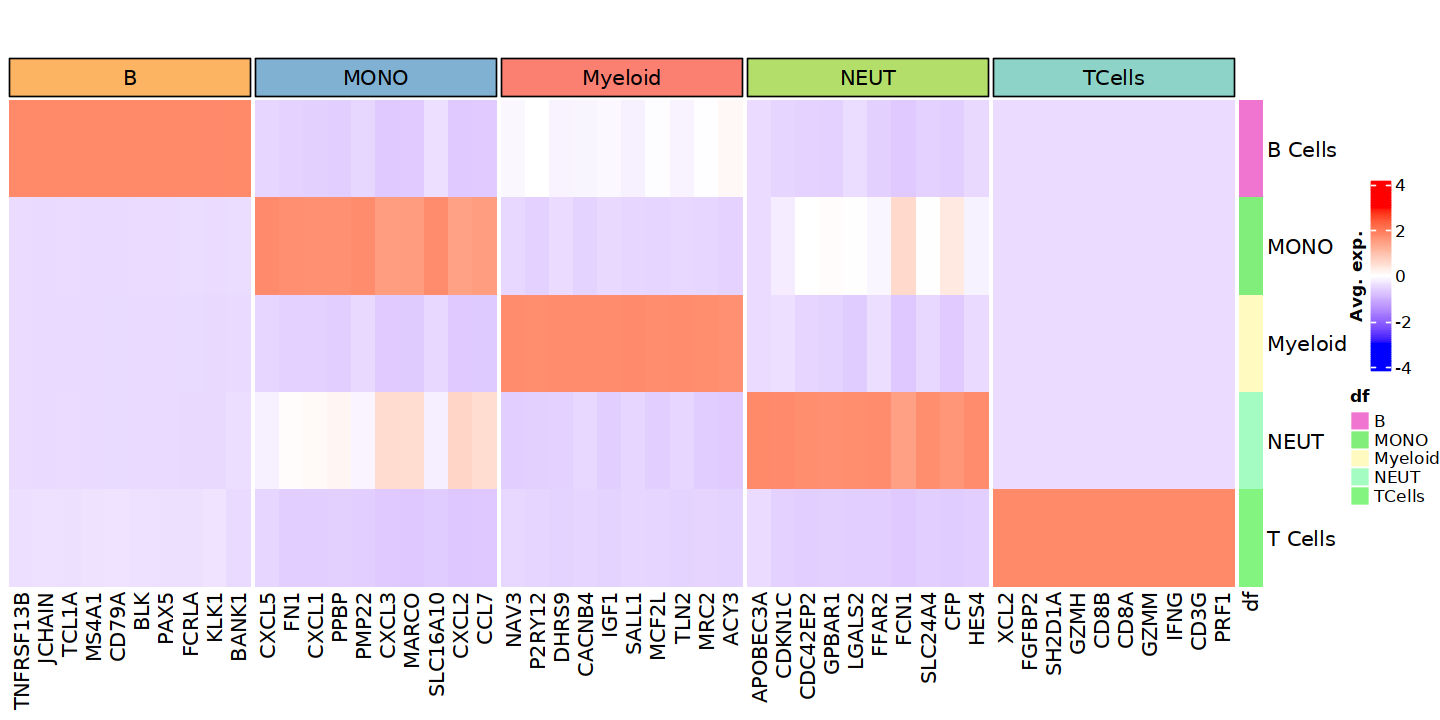

In [7]:
# Generate the heatmap
heatmap_plot = ComplexHeatmap::Heatmap(
    mat, name = "Avg. exp.",                                        # Main data for the heatmap and its title
    cluster_columns = FALSE,                                       # Disable clustering for columns
    cluster_rows = FALSE,                                          # Disable clustering for rows
    col = colorRamp2(c(-3, 0, 3), c("blue", "white", "red")),      # Color scale from blue to red
    column_split = split,                                          # Split columns based on the 'split' vector
    show_row_names = TRUE,                                         # Display row names
    column_order = genes,                                          # Order of columns
    top_annotation = ha,                                           # Top annotation
    right_annotation = ha1,                                        # Right-side annotation
    row_title = NULL,                                              # No row title
    column_title = NULL,                                           # No column title
    
    # Parameters for the heatmap legend
    heatmap_legend_param = list(
        at = c(-4, -2, 0, 2, 4),                                   # Legend breaks
        title = "Avg. exp.",                                       # Legend title
        legend_height = unit(4, "cm"),                             # Legend height
        title_position = "leftcenter-rot"                          # Title position
    )
)

# Set larger dimensions for the plot
options(repr.plot.width = 12, repr.plot.height = 6)

if(save_plot){
    # Save Plot
    pdf('Figure1_D.pdf', width = 12, height = 6)
    heatmap_plot
    dev.off()
}else{
    # Display the heatmap
    heatmap_plot
}


# Session Info

In [8]:
sessionInfo()

R version 4.3.0 (2023-04-21)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 9.4 (Blue Onyx)

Matrix products: default
BLAS/LAPACK: /sc/arion/work/kyriad02/miniconda3/envs/dreamlet430/lib/libopenblasp-r0.3.23.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] grid      stats4    stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] lubridate_1.9.2             forcats_1.0.0              
 [3] stringr_1.5.0               purrr_1.0.1                
 [5] readr_2.1.4                 tibble_3.2.1     